/tmp/ipykernel_2146985/2902277119.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  G = pd.read_csv(gnss_path, header=None, delim_whitespace=True, names=cols)
/tmp/ipykernel_2146985/2902277119.py:84: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  return ds.interp(time=target)
/tmp/ipykernel_2146985/2902277119.py:84: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from panda

{'best_depth_km': 32.0, 'best_log10_eta': 18.5, 'chi2_min': 64190.53682396461, 'redchi2_min': 254.72435247605006, 'nu': 252, 'Nd': 16, 'Ne': 7, 'models_used': 112}


/tmp/ipykernel_2146985/2902277119.py:84: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  return ds.interp(time=target)


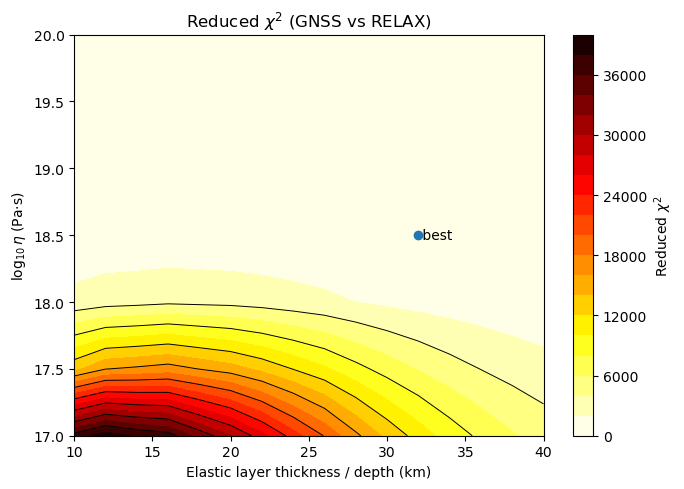

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import glob, os, re
from datetime import datetime
from numpy.linalg import LinAlgError
import geopandas as gpd

# -------------------- USER SETTINGS --------------------
# GNSS table (your file):
gnss_path = "/scratch/eemne/github/VELMAP/examples/TR_postseismic_cum-18092025/velmap_gnss/postseismic_gnss_20241230.dat"

# Folder pattern that contains all your NetCDFs (adjust if needed):
nc_glob = "/scratch/eemne/github/3D_InSAR_dataset/relax_models/2.viscoelastic/2layer_maxwell/2layer_maxwell_t1-10000-40000_t2-17-20/**/relax_timeslice_0.04.nc"

# Target epoch to compare (from your filename it looks like 2024-12-30)
target_date = np.datetime64("2024-12-30")

#fault
gdf = gpd.read_file("/scratch/eemne/github/3D_InSAR_dataset/simple_fault/simple_fault_2023-2-14.shp")
# 2. Make sure CRS is geographic (lon/lat)
if gdf.crs is not None and not gdf.crs.is_geographic:
    gdf = gdf.to_crs("EPSG:4326")
    
breakpoint()

# Treat off-diagonal covariances?
USE_FULL_COV = True   # if False, uses only stde/stdn/stdu as diagonal σ

# Optional: drop stations outside the model domain automatically
DROP_OUTSIDE = True

# Degrees of freedom reduction for nuisance parameters (offset, etc.)
M_nuisance = 0

# ------------------------------------------------------


# ---- 1) Load GNSS observations ----
cols = ['lon','lat','ve','vn','vu','stde','stdn','stdu','coven','coveu','covnu','staid','type','study']
G = pd.read_csv(gnss_path, header=None, delim_whitespace=True, names=cols)
G = G[G['staid'] != 'dummy'].reset_index(drop=True)  # remove dummy rows if any

breakpoint))
# Keep only columns we need
lon = G['lon'].to_numpy()
lat = G['lat'].to_numpy()
obsE = G['ve'].to_numpy()
obsN = G['vn'].to_numpy()
obsU = G['vu'].to_numpy()

# Standard deviations (same units as obs)
sigE = np.clip(G['stde'].to_numpy(), 1e-12, np.inf)
sigN = np.clip(G['stdn'].to_numpy(), 1e-12, np.inf)
sigU = np.clip(G['stdu'].to_numpy(), 1e-12, np.inf)

# Cross-covariances per station (E–N, E–U, N–U). Many tables use 0 when unknown.
covEN = G['coven'].to_numpy()
covEU = G['coveu'].to_numpy()
covNU = G['covnu'].to_numpy()

n_sta = len(G)

# ---- 2) Helpers ----
def parse_depth_logeta_from_path(path: str):
    """
    Extract elastic layer thickness (depth) and log10 viscosity from a path like:
    .../2layer_maxwell_t1-16000m_eta-1e18p5/relax_timeslice_0.04.nc
    Returns (depth_km, log10_eta) as floats.
    """
    # t1-<meters>m
    m_depth = re.search(r"t1-(\d+)m", path)
    if not m_depth:
        raise ValueError(f"Cannot parse t1 depth from: {path}")
    depth_km = float(m_depth.group(1)) / 1000.0

    # eta-1e<digits>(p5)?
    m_eta = re.search(r"eta-1e(\d+)(p5)?", path)
    if not m_eta:
        raise ValueError(f"Cannot parse eta from: {path}")
    base = float(m_eta.group(1))
    half = 0.5 if m_eta.group(2) else 0.0
    log10_eta = base + half
    return depth_km, log10_eta

def time_interp_to(ds: xr.Dataset, target: np.datetime64) -> xr.Dataset:
    """Return ds interpolated (or nearest) in time to 'target'."""
    if "time" not in ds.dims:
        return ds
    # linear if possible, else nearest
    try:
        return ds.interp(time=target)
    except Exception:
        # fallback to nearest index
        it = int(np.argmin(np.abs(ds["time"].values - target)))
        return ds.isel(time=it)
    
def station_chi2_EU(resE, resU, sigE, sigU, covEU, use_full_cov=True):
    """
    Per-station contribution to χ² using ONLY E and U components.

    If use_full_cov:
        r = [rE, rU]
        C = [[sigE^2, covEU],
             [covEU,  sigU^2]]
        χ² = r^T C^{-1} r
    Else:
        χ² = (rE/sigE)^2 + (rU/sigU)^2
    """
    if not use_full_cov:
        return (resE / sigE)**2 + (resU / sigU)**2

    C = np.array([[sigE**2, covEU],
                  [covEU,    sigU**2]], dtype=float)

    eps = 1e-10
    try:
        Ci = np.linalg.inv(C)
    except LinAlgError:
        Ci = np.linalg.inv(C + eps*np.eye(2))

    r = np.array([resE, resU], dtype=float)
    return float(r @ Ci @ r)

def interp_components_at_stations(ds: xr.Dataset, lons, lats):
    """
    Interpolate model E/N/U at given station coords.
    Expects ds with coords 'lon','lat' and data_vars 'E','N','U'.
    Returns 3 arrays (predE, predN, predU) of length n_sta.
    """
    # xarray can vectorize interpolation using DataArray of points
    pts_lon = xr.DataArray(lons, dims="pts")
    pts_lat = xr.DataArray(lats, dims="pts")
    sub = ds[["E","N","U"]].interp(lon=pts_lon, lat=pts_lat, method="linear")
    # shape: (pts,)
    return (sub["E"].values, sub["N"].values, sub["U"].values)

def station_chi2(resE, resN, resU, sigE, sigN, sigU, covEN, covEU, covNU, use_full_cov=True):
    """
    Per-station contribution to χ².
    If use_full_cov: χ²_i = r^T C^{-1} r with C 3x3 using sd + cross-cov.
    Else: diagonal only: (rE/sE)^2 + (rN/sN)^2 + (rU/sU)^2.
    """
    if not use_full_cov:
        return (resE/sigE)**2 + (resN/sigN)**2 + (resU/sigU)**2

    # Build covariance matrix C (3x3). Variances on diagonal, given s^2.
    C = np.array([[sigE**2, covEN,    covEU   ],
                  [covEN,    sigN**2, covNU   ],
                  [covEU,    covNU,   sigU**2 ]], dtype=float)

    # Guard against singular/negative-definite matrices
    # Regularize gently if needed
    eps = 1e-10
    try:
        Ci = np.linalg.inv(C)
    except LinAlgError:
        Ci = np.linalg.inv(C + eps*np.eye(3))

    r = np.array([resE, resN, resU], dtype=float)
    return float(r @ Ci @ r)

# ---- 3) Discover all model files and parse their parameters ----
nc_files = sorted(glob.glob(nc_glob, recursive=True))
if not nc_files:
    raise SystemExit("No NetCDFs found; check nc_glob.")

param_list = []
for p in nc_files:
    try:
        dkm, logeta = parse_depth_logeta_from_path(p)
        param_list.append((p, dkm, logeta))
    except Exception as e:
        print(f"Skip (parse failed): {p} ({e})")

if not param_list:
    raise SystemExit("Could not parse any (depth, log10η) from paths.")

# Unique sorted parameter axes
depth_vals   = sorted({dkm for _, dkm, _ in param_list})
logeta_vals  = sorted({le  for _, _, le in param_list})

Nd, Ne = len(depth_vals), len(logeta_vals)
chi2 = np.full((Nd, Ne), np.nan)

# ---- 4) Main loop: compute χ² per model ----
for path, dkm, le in param_list:
    # indices in grid
    i = depth_vals.index(dkm)
    j = logeta_vals.index(le)

    ds = xr.open_dataset(path)

    # Optional: restrict to target date
    ds_t = time_interp_to(ds, target_date)

    # Interpolate predictions at station locations
    predE, predN, predU = interp_components_at_stations(ds_t, lon, lat)

    # If a station falls outside the grid, interpolation gives NaN
    valid = np.isfinite(predE) & np.isfinite(predN) & np.isfinite(predU)
    if DROP_OUTSIDE:
        vv = valid
    else:
        # if any NaN appears, skip this model as incomparable
        if not np.all(valid):
            print(f"Model {os.path.basename(os.path.dirname(path))}: some stations outside grid -> skipping.")
            continue
        vv = np.ones_like(valid, dtype=bool)

    # Residuals (obs - model)
    rE = obsE[vv] - predE[vv]
    rN = obsN[vv] - predN[vv]
    rU = obsU[vv] - predU[vv]

    # Uncertainties / covariances for valid stations
    sE = sigE[vv]; sN = sigN[vv]; sU = sigU[vv]
    cEN = covEN[vv]; cEU = covEU[vv]; cNU = covNU[vv]

    # Sum χ² over stations (3 comps per station)
    chi2_sum = 0.0
    for k in range(rE.size):
        chi2_sum += station_chi2(rE[k], rN[k], rU[k], sE[k], sN[k], sU[k], cEN[k], cEU[k], cNU[k], use_full_cov=USE_FULL_COV)

    chi2[i, j] = chi2_sum

# ---- 5) Reduced χ² and best fit ----
# N_eff = 3 * (# valid stations used). Crude but serviceable: assume all models used the same valid set.
# If DROP_OUTSIDE=True, N_eff may vary across models; for rigor, track per-model ν.
# Here we compute ν from the first finite χ² cell:
finite_idx = np.argwhere(np.isfinite(chi2))
if finite_idx.size == 0:
    raise SystemExit("All χ² are NaN; likely all models miss the station domain.")
i0, j0 = finite_idx[0]
# Recompute N_eff at that model for ν:
ds0 = xr.open_dataset(param_list[i0*Ne + j0][0])
ds0t = time_interp_to(ds0, target_date)
pE0, pN0, pU0 = interp_components_at_stations(ds0t, lon, lat)
valid0 = np.isfinite(pE0) & np.isfinite(pN0) & np.isfinite(pU0)
N_eff = 3 * int(np.count_nonzero(valid0))

nu = max(N_eff - M_nuisance, 1)
redchi2 = chi2 / nu

# Best fit
best = np.unravel_index(np.nanargmin(chi2), chi2.shape)
best_depth = depth_vals[best[0]]
best_logeta = logeta_vals[best[1]]
chi2_min = float(chi2[best])
red_min = float(redchi2[best])

print({
    "best_depth_km": best_depth,
    "best_log10_eta": best_logeta,
    "chi2_min": chi2_min,
    "redchi2_min": red_min,
    "nu": int(nu),
    "Nd": Nd, "Ne": Ne, "models_used": int(np.isfinite(chi2).sum())
})

# ---- 6) Plot reduced-χ² map ----
D, E = np.meshgrid(depth_vals, logeta_vals, indexing="xy")
fig, ax = plt.subplots(figsize=(7,5))
cf = ax.contourf(D, E, redchi2.T, levels=24, cmap="hot_r")
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Reduced $\\chi^2$")

# Thin χ² contours for structure
ax.contour(D, E, chi2.T, levels=10, colors="k", linewidths=0.7)

ax.plot([best_depth], [best_logeta], "o")
ax.text(best_depth, best_logeta, " best", va="center", ha="left")
ax.set_xlabel("Elastic layer thickness / depth (km)")
ax.set_ylabel("$\\log_{10}\\,\\eta$ (Pa·s)")
ax.set_title("Reduced $\\chi^2$ (GNSS vs RELAX)")
fig.tight_layout()
plt.show()


/tmp/ipykernel_2146985/1513956090.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  G = pd.read_csv(gnss_path, header=None, delim_whitespace=True, names=cols)
/tmp/ipykernel_2146985/1513956090.py:79: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  return ds.interp(time=target)
/tmp/ipykernel_2146985/1513956090.py:79: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from panda

{'best_depth_km': 30.0, 'best_log10_eta': 18.5, 'chi2_min': 29670.16028568584, 'redchi2_min': 176.6080969386062, 'nu': 168, 'Nd': 16, 'Ne': 7, 'models_used': 112}


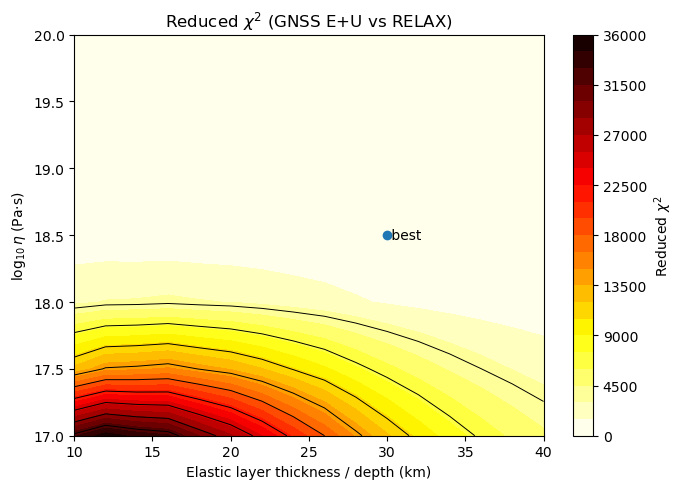

In [4]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import glob, os, re
from datetime import datetime
from numpy.linalg import LinAlgError

# -------------------- USER SETTINGS --------------------
# GNSS table (your file):
gnss_path = "/scratch/eemne/github/VELMAP/examples/TR_postseismic_cum-18092025/velmap_gnss/postseismic_gnss_20241230.dat"

# Folder pattern that contains all your NetCDFs (adjust if needed):
nc_glob = "/scratch/eemne/github/3D_InSAR_dataset/relax_models/2.viscoelastic/2layer_maxwell/2layer_maxwell_t1-10000-40000_t2-17-20/**/relax_timeslice_0.04.nc"

# Target epoch to compare (from your filename it looks like 2024-12-30)
target_date = np.datetime64("2024-12-30")

# Treat off-diagonal covariances? (here: only the E–U block matters)
USE_FULL_COV = True   # if False, uses only stde/stdu as diagonal σ

# Optional: drop stations outside the model domain automatically
DROP_OUTSIDE = True

# Degrees of freedom reduction for nuisance parameters (offset, etc.)
M_nuisance = 0
# ------------------------------------------------------


# ---- 1) Load GNSS observations ----
cols = ['lon','lat','ve','vn','vu','stde','stdn','stdu','coven','coveu','covnu','staid','type','study']
G = pd.read_csv(gnss_path, header=None, delim_whitespace=True, names=cols)
G = G[G['staid'] != 'dummy'].reset_index(drop=True)  # remove dummy rows if any

# Keep only columns we need
lon = G['lon'].to_numpy()
lat = G['lat'].to_numpy()
obsE = G['ve'].to_numpy()
obsU = G['vu'].to_numpy()

# Standard deviations (same units as obs)
sigE = np.clip(G['stde'].to_numpy(), 1e-12, np.inf)
sigU = np.clip(G['stdu'].to_numpy(), 1e-12, np.inf)

# Cross-covariance per station for E–U
covEU = G['coveu'].to_numpy()

n_sta = len(G)


# ---- 2) Helpers ----
def parse_depth_logeta_from_path(path: str):
    """
    Extract elastic layer thickness (depth) and log10 viscosity from a path like:
    .../2layer_maxwell_t1-16000m_eta-1e18p5/relax_timeslice_0.04.nc
    Returns (depth_km, log10_eta) as floats.
    """
    # t1-<meters>m
    m_depth = re.search(r"t1-(\d+)m", path)
    if not m_depth:
        raise ValueError(f"Cannot parse t1 depth from: {path}")
    depth_km = float(m_depth.group(1)) / 1000.0

    # eta-1e<digits>(p5)?
    m_eta = re.search(r"eta-1e(\d+)(p5)?", path)
    if not m_eta:
        raise ValueError(f"Cannot parse eta from: {path}")
    base = float(m_eta.group(1))
    half = 0.5 if m_eta.group(2) else 0.0
    log10_eta = base + half
    return depth_km, log10_eta


def time_interp_to(ds: xr.Dataset, target: np.datetime64) -> xr.Dataset:
    """Return ds interpolated (or nearest) in time to 'target'."""
    if "time" not in ds.dims:
        return ds
    try:
        return ds.interp(time=target)
    except Exception:
        it = int(np.argmin(np.abs(ds["time"].values - target)))
        return ds.isel(time=it)


def interp_components_at_stations(ds: xr.Dataset, lons, lats):
    """
    Interpolate model E/N/U at given station coords.
    Expects ds with coords 'lon','lat' and data_vars 'E','N','U'.
    Returns 3 arrays (predE, predN, predU) of length n_sta.
    """
    pts_lon = xr.DataArray(lons, dims="pts")
    pts_lat = xr.DataArray(lats, dims="pts")
    sub = ds[["E","N","U"]].interp(lon=pts_lon, lat=pts_lat, method="linear")
    return (sub["E"].values, sub["N"].values, sub["U"].values)


def station_chi2_EU(resE, resU, sigE, sigU, covEU, use_full_cov=True):
    """
    Per-station contribution to χ² using ONLY E and U components.

    If use_full_cov:
        r = [rE, rU]
        C = [[sigE^2, covEU],
             [covEU,  sigU^2]]
        χ² = r^T C^{-1} r
    Else:
        χ² = (rE/sigE)^2 + (rU/sigU)^2
    """
    if not use_full_cov:
        return (resE / sigE)**2 + (resU / sigU)**2

    C = np.array([[sigE**2, covEU],
                  [covEU,    sigU**2]], dtype=float)

    eps = 1e-10
    try:
        Ci = np.linalg.inv(C)
    except LinAlgError:
        Ci = np.linalg.inv(C + eps*np.eye(2))

    r = np.array([resE, resU], dtype=float)
    return float(r @ Ci @ r)


# ---- 3) Discover all model files and parse their parameters ----
nc_files = sorted(glob.glob(nc_glob, recursive=True))
if not nc_files:
    raise SystemExit("No NetCDFs found; check nc_glob.")

param_list = []
for p in nc_files:
    try:
        dkm, logeta = parse_depth_logeta_from_path(p)
        param_list.append((p, dkm, logeta))
    except Exception as e:
        print(f"Skip (parse failed): {p} ({e})")

if not param_list:
    raise SystemExit("Could not parse any (depth, log10η) from paths.")

# Unique sorted parameter axes
depth_vals   = sorted({dkm for _, dkm, _ in param_list})
logeta_vals  = sorted({le  for _, _, le in param_list})

Nd, Ne = len(depth_vals), len(logeta_vals)
chi2 = np.full((Nd, Ne), np.nan)

# Helpful map from (depth, logeta) to path for later ν calc
path_by_param = {(dkm, le): path for (path, dkm, le) in param_list}


# ---- 4) Main loop: compute χ² per model (E & U only) ----
for path, dkm, le in param_list:
    i = depth_vals.index(dkm)
    j = logeta_vals.index(le)

    ds = xr.open_dataset(path)

    # Optional: restrict to target date
    ds_t = time_interp_to(ds, target_date)

    # Interpolate predictions at station locations
    predE, _, predU = interp_components_at_stations(ds_t, lon, lat)

    # Only require E and U to be finite
    valid = np.isfinite(predE) & np.isfinite(predU)
    if DROP_OUTSIDE:
        vv = valid
    else:
        if not np.all(valid):
            print(f"Model {os.path.basename(os.path.dirname(path))}: some stations outside grid (E/U) -> skipping.")
            continue
        vv = np.ones_like(valid, dtype=bool)

    # Residuals (obs - model) for E and U only
    rE = obsE[vv] - predE[vv]
    rU = obsU[vv] - predU[vv]

    # Uncertainties / covariance for E & U
    sE = sigE[vv]; sU = sigU[vv]
    cEU = covEU[vv]

    # Sum χ² over stations (2 comps per station)
    chi2_sum = 0.0
    for k in range(rE.size):
        chi2_sum += station_chi2_EU(rE[k], rU[k], sE[k], sU[k], cEU[k], use_full_cov=USE_FULL_COV)

    chi2[i, j] = chi2_sum


# ---- 5) Reduced χ² and best fit ----
# ν (degrees of freedom): 2 per valid station (E & U), minus nuisance params.
finite_idx = np.argwhere(np.isfinite(chi2))
if finite_idx.size == 0:
    raise SystemExit("All χ² are NaN; likely all models miss the station domain (E/U).")

i0, j0 = finite_idx[0]
dkm0 = depth_vals[i0]
le0  = logeta_vals[j0]
path0 = path_by_param[(dkm0, le0)]

ds0 = xr.open_dataset(path0)
ds0t = time_interp_to(ds0, target_date)
pE0, _, pU0 = interp_components_at_stations(ds0t, lon, lat)
valid0 = np.isfinite(pE0) & np.isfinite(pU0)
N_eff = 2 * int(np.count_nonzero(valid0))   # 2 comps/station (E,U)

nu = max(N_eff - M_nuisance, 1)
redchi2 = chi2 / nu

# Best fit
best = np.unravel_index(np.nanargmin(chi2), chi2.shape)
best_depth = depth_vals[best[0]]
best_logeta = logeta_vals[best[1]]
chi2_min = float(chi2[best])
red_min = float(redchi2[best])

print({
    "best_depth_km": best_depth,
    "best_log10_eta": best_logeta,
    "chi2_min": chi2_min,
    "redchi2_min": red_min,
    "nu": int(nu),
    "Nd": Nd, "Ne": Ne, "models_used": int(np.isfinite(chi2).sum())
})


# ---- 6) Plot reduced-χ² map ----
D, E = np.meshgrid(depth_vals, logeta_vals, indexing="xy")
fig, ax = plt.subplots(figsize=(7,5))
cf = ax.contourf(D, E, redchi2.T, levels=24, cmap="hot_r")
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Reduced $\\chi^2$")

# Thin χ² contours for structure
ax.contour(D, E, chi2.T, levels=10, colors="k", linewidths=0.7)

ax.plot([best_depth], [best_logeta], "o")
ax.text(best_depth, best_logeta, " best", va="center", ha="left")
ax.set_xlabel("Elastic layer thickness / depth (km)")
ax.set_ylabel("$\\log_{10}\\,\\eta$ (Pa·s)")
ax.set_title("Reduced $\\chi^2$ (GNSS E+U vs RELAX)")
fig.tight_layout()
plt.show()
